<a href="https://colab.research.google.com/github/muhammadfathanfuad/project-machineLearning/blob/main/Case_Project_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Analisis Faktor Gaya Hidup dan Lingkungan Kerja terhadap Risiko Burnout pada Pekerja Remote.**

## **Import library yang dibutuhkan**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## **1. LOAD DATASET**

In [ ]:
df = pd.read_csv('synthetic_employee_burnout.csv')

print("=== 5 Baris Pertama Dataset ===")
display(df.head())

=== 5 Baris Pertama Dataset ===


,Name,Age,Gender,JobRole,Experience,WorkHoursPerWeek,RemoteRatio,SatisfactionLevel,StressLevel,Burnout
0,Max Ivanov,32,Male,Analyst,3,60,21,4.40,1,0
1,Max Wang,40,Female,Engineer,9,47,67,2.09,2,0
2,Nina Petrov,33,Female,Engineer,2,44,20,2.58,3,0
3,John Ivanov,35,Female,Manager,6,44,70,3.23,8,0
4,John Wang,59,Male,Sales,8,38,46,4.41,1,0


## **2. DATA UNDERSTANDING**

In [ ]:
print("\n=== Informasi Tipe Data ===")
df.info()

print("\n=== Pengecekan Missing Values ===")
print(df.isnull().sum())

print("\n2. Statistik Deskriptif (Melihat sebaran nilai min, max, mean):")
display(df.describe())


=== Informasi Tipe Data ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               2000 non-null   object 
 1   Age                2000 non-null   int64  
 2   Gender             2000 non-null   object 
 3   JobRole            2000 non-null   object 
 4   Experience         2000 non-null   int64  
 5   WorkHoursPerWeek   2000 non-null   int64  
 6   RemoteRatio        2000 non-null   int64  
 7   SatisfactionLevel  2000 non-null   float64
 8   StressLevel        2000 non-null   int64  
 9   Burnout            2000 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 156.4+ KB

=== Pengecekan Missing Values ===
Name                 0
Age                  0
Gender               0
JobRole              0
Experience           0
WorkHoursPerWeek     0
RemoteRatio          0
SatisfactionLevel    0
Stres

,Age,Experience,WorkHoursPerWeek,RemoteRatio,SatisfactionLevel,StressLevel,Burnout
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,40.694500,10.074500,49.588000,49.973000,2.995230,5.43200,0.064500
std,11.286756,9.148267,11.832424,29.151298,1.155431,2.88089,0.245703
min,22.000000,0.000000,30.000000,0.000000,1.000000,1.00000,0.000000
25%,31.000000,3.000000,39.000000,24.000000,2.000000,3.00000,0.000000
50%,41.000000,7.000000,49.000000,49.000000,3.025000,5.00000,0.000000
75%,50.000000,15.000000,60.000000,75.000000,4.000000,8.00000,0.000000
max,60.000000,39.000000,70.000000,100.000000,5.000000,10.00000,1.000000


## **3. DATA PREPROCESSING (ENCODING)**

In [ ]:
print("\n=== TAHAP 2: DATA PREPROCESSING ===")

# A. Menghapus Kolom Tidak Relevan
if 'Name' in df.columns:
    df = df.drop('Name', axis=1)
    print("- Kolom 'name' berhasil dihapus.")

# B. Menyalin Data untuk Keperluan Model
df_model = df.copy()

# C. Encoding Data Kategorikal
df_model = pd.get_dummies(df_model, columns=['Gender', 'JobRole'], drop_first=True, dtype=int)
print("- One-Hot Encoding untuk 'gender' dan 'jobrole' selesai.")

# E. Normalisasi / Standarisasi Data
numeric_features = ['Age', 'Experience', 'WorkHoursPerWeek', 'RemoteRatio', 'SatisfactionLevel', 'StressLevel']
scaler = StandardScaler()
df_model[numeric_features] = scaler.fit_transform(df_model[numeric_features])
print("- Standarisasi (Scaling) fitur numerik selesai.")

print("\n3. Tampilan Data Final Setelah Preprocessing (Siap untuk Machine Learning):")
display(df_model.head())


=== TAHAP 2: DATA PREPROCESSING ===
- Kolom 'name' berhasil dihapus.
- One-Hot Encoding untuk 'gender' dan 'jobrole' selesai.
- Standarisasi (Scaling) fitur numerik selesai.

3. Tampilan Data Final Setelah Preprocessing (Siap untuk Machine Learning):


,Age,Experience,WorkHoursPerWeek,RemoteRatio,SatisfactionLevel,StressLevel,Burnout,Gender_Male,JobRole_Engineer,JobRole_HR,JobRole_Manager,JobRole_Sales
0,-0.770520,-0.773509,0.880175,-0.994132,1.216101,-1.538798,0,1,0,0,0,0
1,-0.061548,-0.117483,-0.218776,0.584237,-0.783652,-1.191597,0,0,1,0,0,0
2,-0.681899,-0.882847,-0.472380,-1.028445,-0.359462,-0.844395,0,0,1,0,0,0
3,-0.504656,-0.445496,-0.472380,0.687174,0.203239,0.891614,0,0,0,0,1,0
4,1.622262,-0.226821,-0.979588,-0.136323,1.224758,-1.538798,0,1,0,0,0,1


## **4. EXPLORATORY DATA ANALYSIS (EDA)**

=== TAHAP 3: EXPLORATORY DATA ANALYSIS ===


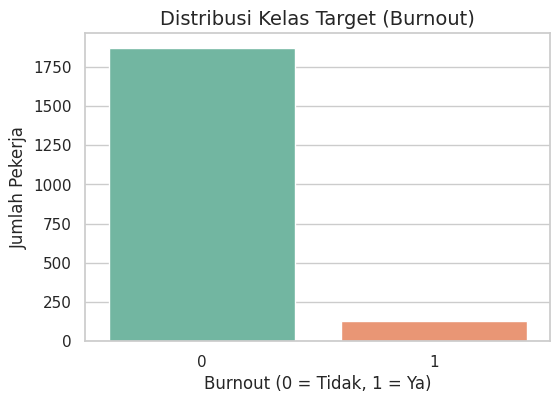

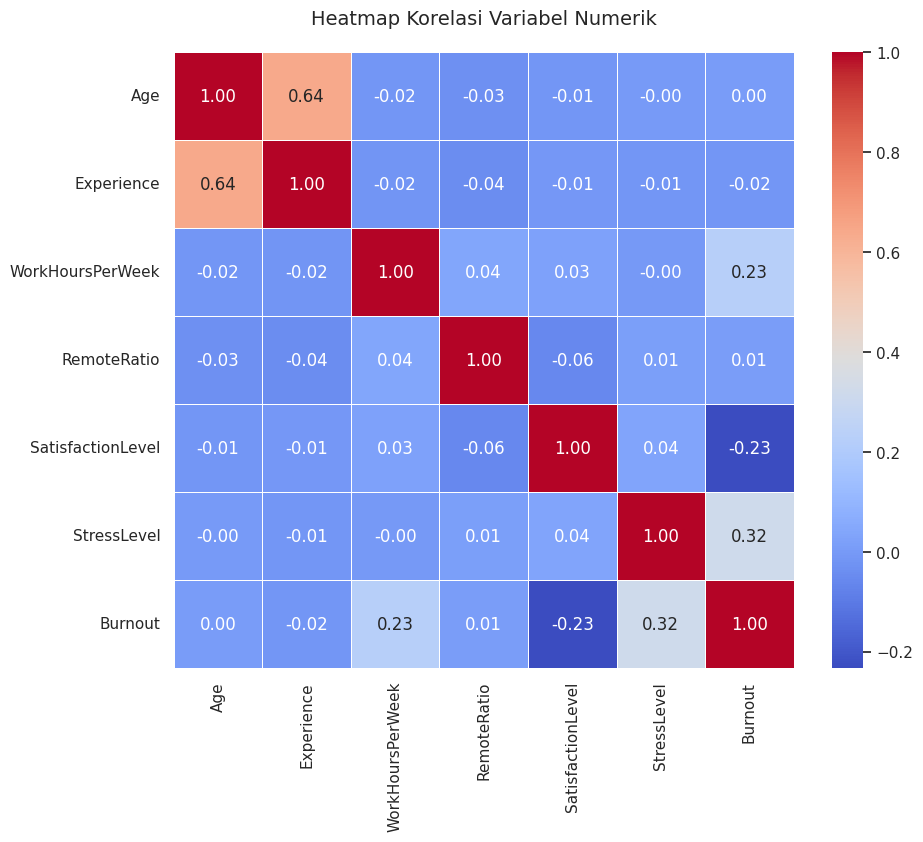

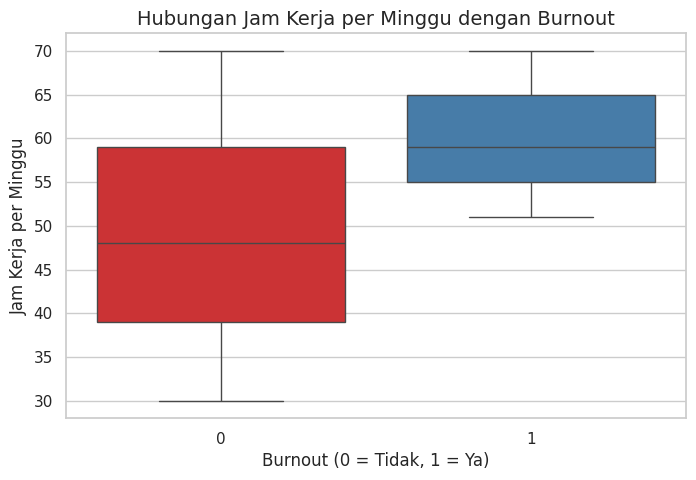

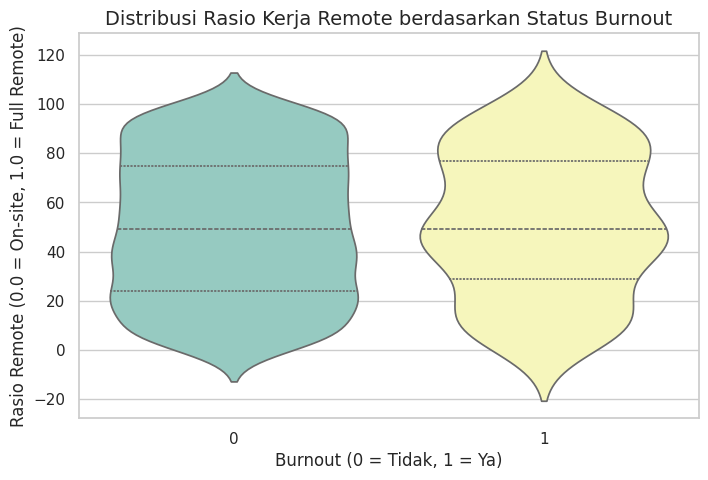

In [ ]:
print("=== TAHAP 3: EXPLORATORY DATA ANALYSIS ===")

# Mengatur tema visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- 1. Distribusi Kelas Target (Burnout) ---
plt.figure(figsize=(6, 4))
# Menambahkan hue='Burnout' dan legend=False sesuai anjuran Seaborn
sns.countplot(data=df, x='Burnout', hue='Burnout', palette='Set2', legend=False)
plt.title('Distribusi Kelas Target (Burnout)', fontsize=14)
plt.xlabel('Burnout (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Pekerja')
plt.show()

# --- 2. Korelasi Antar Fitur Numerik ---
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Variabel Numerik', fontsize=14, pad=20)
plt.show()

# --- 3. Gaya Hidup: Jam Kerja vs Burnout ---
plt.figure(figsize=(8, 5))
# Menyesuaikan huruf kapital nama kolom dan menambah hue
sns.boxplot(data=df, x='Burnout', y='WorkHoursPerWeek', hue='Burnout', palette='Set1', legend=False)
plt.title('Hubungan Jam Kerja per Minggu dengan Burnout', fontsize=14)
plt.xlabel('Burnout (0 = Tidak, 1 = Ya)')
plt.ylabel('Jam Kerja per Minggu')
plt.show()

# --- 4. Lingkungan Kerja: Rasio Remote vs Burnout ---
plt.figure(figsize=(8, 5))
# Menyesuaikan huruf kapital nama kolom dan menambah hue
sns.violinplot(data=df, x='Burnout', y='RemoteRatio', hue='Burnout', palette='Set3', inner="quartile", legend=False)
plt.title('Distribusi Rasio Kerja Remote berdasarkan Status Burnout', fontsize=14)
plt.xlabel('Burnout (0 = Tidak, 1 = Ya)')
plt.ylabel('Rasio Remote (0.0 = On-site, 1.0 = Full Remote)')
plt.show()

## 5. **DATA SPLITTING & HANDLING IMBALANCE**

In [ ]:
print("=== TAHAP 4: DATA SPLITTING ===")

# 1. Memisahkan Fitur (X) dan Target (y)
# menggunakan df_model yang sudah di-encode dan di-scale pada Tahap 2
X = df_model.drop('Burnout', axis=1)
y = df_model['Burnout']

# 2. Menyiapkan 3 variasi pembagian data sesuai instruksi tugas
# Representasi testing: 30%, 20%, dan 10%
test_sizes = [0.3, 0.2, 0.1]

# Dictionary untuk menyimpan hasil split
data_splits = {}

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

for test_size in test_sizes:
    # Nama rasio untuk kemudahan pelabelan (misal: 70:30)
    ratio_name = f"{int((1-test_size)*100)}:{int(test_size*100)}"

    # Melakukan Data Splitting
    # stratify=y memastikan proporsi kelas 0 dan 1 tetap sama antara data train dan test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

    # Menerapkan SMOTE khusus pada data training untuk menyeimbangkan kelas
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    # Menyimpan hasil ke dalam dictionary
    data_splits[ratio_name] = {
        'X_train': X_train_smote,
        'X_test': X_test,
        'y_train': y_train_smote,
        'y_test': y_test
    }

    print(f"\n--- Rasio Splitting {ratio_name} ---")
    print(f"Data Training (Asli)       : {len(X_train)} baris")
    print(f"Data Training (SMOTE)      : {len(X_train_smote)} baris -> Kelas 0: {sum(y_train_smote==0)}, Kelas 1: {sum(y_train_smote==1)}")
    print(f"Data Testing (Asli)        : {len(X_test)} baris -> Kelas 0: {sum(y_test==0)}, Kelas 1: {sum(y_test==1)}")

print("\nTahap Data Splitting dengan 3 kombinasi rasio berhasil dilakukan!")

=== TAHAP 4: DATA SPLITTING ===

--- Rasio Splitting 70:30 ---
Data Training (Asli)       : 1400 baris
Data Training (SMOTE)      : 2620 baris -> Kelas 0: 1310, Kelas 1: 1310
Data Testing (Asli)        : 600 baris -> Kelas 0: 561, Kelas 1: 39

--- Rasio Splitting 80:20 ---
Data Training (Asli)       : 1600 baris
Data Training (SMOTE)      : 2994 baris -> Kelas 0: 1497, Kelas 1: 1497
Data Testing (Asli)        : 400 baris -> Kelas 0: 374, Kelas 1: 26

--- Rasio Splitting 90:10 ---
Data Training (Asli)       : 1800 baris
Data Training (SMOTE)      : 3368 baris -> Kelas 0: 1684, Kelas 1: 1684
Data Testing (Asli)        : 200 baris -> Kelas 0: 187, Kelas 1: 13

Tahap Data Splitting dengan 3 kombinasi rasio berhasil dilakukan!


## **6 & 7: MODEL BUILDING & HYPERPARAMETER TUNING**

In [ ]:
print("=== TAHAP 6 & 7: MODEL BUILDING & TUNING ===")

# 1. Inisialisasi Model Dasar
# Logistic Regression sebagai baseline, Random Forest dan Gradient Boosting sebagai model kompleks
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=2000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# 2. Menentukan Parameter Grid untuk di-Tuning
param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1.0, 10.0],
        'solver': ['liblinear', 'lbfgs']
    },
    'Random Forest': {
        'n_estimators': [50, 100],
        'max_depth': [None, 10, 20]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.1]
    }
}

# Dictionary untuk menyimpan hasil akhir dari semua eksperimen
model_results = {}

# 3. Proses Training dan Tuning Berulang untuk Setiap Rasio Splitting
for ratio_name, split_data in data_splits.items():
    print(f"--- Evaluasi pada Rasio Splitting {ratio_name} ---")

    X_train = split_data['X_train']
    y_train = split_data['y_train']
    X_test = split_data['X_test']
    y_test = split_data['y_test']

    # Menyiapkan tempat penyimpanan hasil untuk rasio ini
    model_results[ratio_name] = {}

    for model_name in models:
        # Menjalankan GridSearchCV
        # cv=3 artinya 3-fold cross-validation, n_jobs=-1
        grid_search = GridSearchCV(
            estimator=models[model_name],
            param_grid=param_grids[model_name],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )

        # Fit (Melatih) model dengan data training yang sudah di-SMOTE
        grid_search.fit(X_train, y_train)

        # Mengambil model dengan settingan terbaik
        best_model = grid_search.best_estimator_

        # Memprediksi data testing (data yang belum pernah dilihat model)
        y_pred = best_model.predict(X_test)

        # Menghitung akurasi prediksi
        acc = accuracy_score(y_test, y_pred)

        # Menyimpan metrik dan prediksi untuk Tahap Evaluasi nanti
        model_results[ratio_name][model_name] = {
            'best_params': grid_search.best_params_,
            'accuracy': acc,
            'best_model': best_model,
            'y_pred': y_pred,
            'y_test': y_test # Disimpan untuk Confusion Matrix di tahap selanjutnya
        }

        print(f"[{model_name}] Akurasi: {acc*100:.2f}% | Best Params: {grid_search.best_params_}")

    print("-" * 60)

print("\nTahap Model Building & Hyperparameter Tuning Selesai!")

=== TAHAP 5 & 6: MODEL BUILDING & TUNING ===
Proses ini akan memakan waktu beberapa saat karena melatih banyak kombinasi model...

--- Evaluasi pada Rasio Splitting 70:30 ---
[Logistic Regression] Akurasi: 93.17% | Best Params: {'C': 1.0, 'solver': 'lbfgs'}
[Random Forest] Akurasi: 100.00% | Best Params: {'max_depth': None, 'n_estimators': 50}
[Gradient Boosting] Akurasi: 100.00% | Best Params: {'learning_rate': 0.1, 'n_estimators': 50}
------------------------------------------------------------
--- Evaluasi pada Rasio Splitting 80:20 ---
[Logistic Regression] Akurasi: 93.00% | Best Params: {'C': 1.0, 'solver': 'lbfgs'}
[Random Forest] Akurasi: 100.00% | Best Params: {'max_depth': None, 'n_estimators': 50}
[Gradient Boosting] Akurasi: 100.00% | Best Params: {'learning_rate': 0.1, 'n_estimators': 50}
------------------------------------------------------------
--- Evaluasi pada Rasio Splitting 90:10 ---
[Logistic Regression] Akurasi: 95.00% | Best Params: {'C': 1.0, 'solver': 'lbfgs'}


## **8. MODEL EVALUATION**

=== TAHAP 7: MODEL EVALUATION ===
--- Laporan Evaluasi Klasifikasi (Rasio Data 80:20) ---

[Logistic Regression]
                   precision    recall  f1-score   support

Tidak Burnout (0)       1.00      0.93      0.96       374
      Burnout (1)       0.48      0.96      0.64        26

         accuracy                           0.93       400
        macro avg       0.74      0.94      0.80       400
     weighted avg       0.96      0.93      0.94       400

-------------------------------------------------------
[Random Forest]
                   precision    recall  f1-score   support

Tidak Burnout (0)       1.00      1.00      1.00       374
      Burnout (1)       1.00      1.00      1.00        26

         accuracy                           1.00       400
        macro avg       1.00      1.00      1.00       400
     weighted avg       1.00      1.00      1.00       400

-------------------------------------------------------
[Gradient Boosting]
                   precis

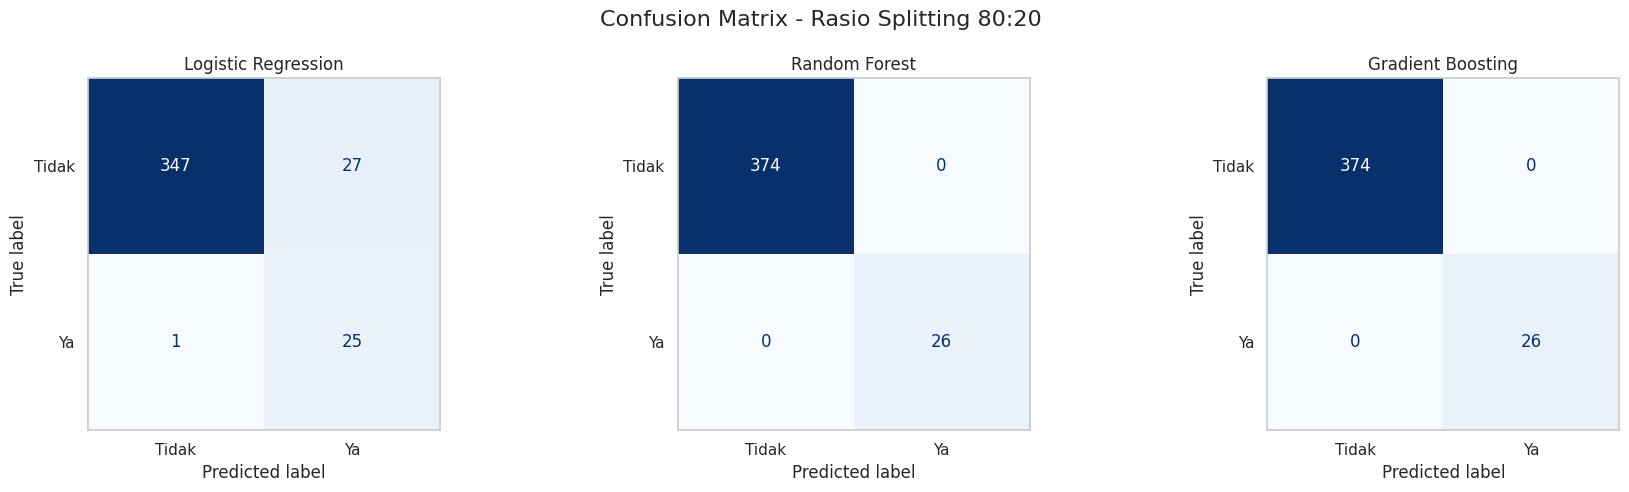

In [ ]:
print("=== TAHAP 8: MODEL EVALUATION ===")

# Kita fokuskan evaluasi visual pada rasio 80:20 untuk dimasukkan ke laporan
ratio_focus = "80:20"
print(f"--- Laporan Evaluasi Klasifikasi (Rasio Data {ratio_focus}) ---\n")

# Membuat figure untuk menampung 3 Confusion Matrix berdampingan
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Confusion Matrix - Rasio Splitting {ratio_focus}', fontsize=16)

# Looping untuk setiap algoritma pada rasio 80:20
for idx, model_name in enumerate(models.keys()):
    # Mengambil data prediksi dan nilai asli dari tahap sebelumnya
    y_test = model_results[ratio_focus][model_name]['y_test']
    y_pred = model_results[ratio_focus][model_name]['y_pred']

    # 1. Menampilkan Classification Report (Precision, Recall, F1-Score)
    print(f"[{model_name}]")
    print(classification_report(y_test, y_pred, target_names=['Tidak Burnout (0)', 'Burnout (1)']))
    print("-" * 55)

    # 2. Membuat Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak', 'Ya'])

    # Plotting ke dalam subplots
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(model_name)
    axes[idx].grid(False)

plt.tight_layout()
plt.show()

## **9. MODEL COMPARISON**

=== TAHAP 8: MODEL COMPARISON ===

--- Tabel Perbandingan Akurasi ---


Data Split,70:30,80:20,90:10
Algoritma,,,
Gradient Boosting,100.00,100.0,100.0
Logistic Regression,93.17,93.0,95.0
Random Forest,100.00,100.0,100.0


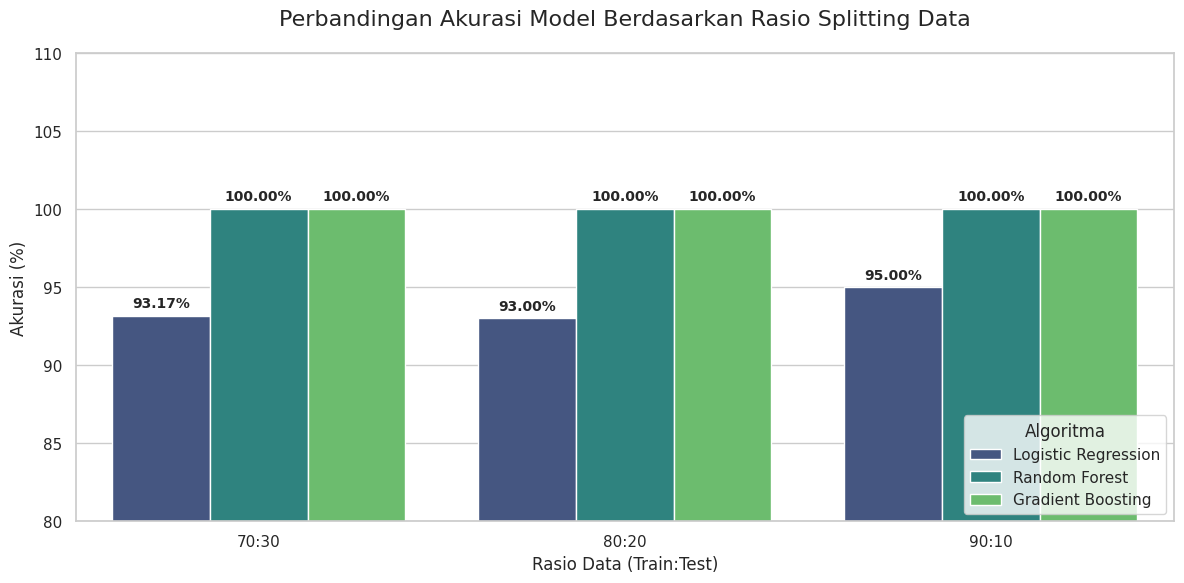


Seluruh tahapan Machine Learning Code telah SELESAI dieksekusi dengan sukses!


In [ ]:
print("=== TAHAP 9: MODEL COMPARISON ===")

# 1. Menyiapkan Data untuk Tabel Perbandingan
comparison_data = []

# Mengambil data dari dictionary hasil training di Tahap 5 & 6
for ratio, models_dict in model_results.items():
    for model_name, metrics in models_dict.items():
        comparison_data.append({
            'Data Split': ratio,
            'Algoritma': model_name,
            'Akurasi (%)': metrics['accuracy'] * 100
        })

# Membuat DataFrame
df_compare = pd.DataFrame(comparison_data)

# Menampilkan Tabel Perbandingan
print("\n--- Tabel Perbandingan Akurasi ---")
df_pivot = df_compare.pivot(index='Algoritma', columns='Data Split', values='Akurasi (%)')
display(df_pivot.round(2))

# 2. Membuat Visualisasi Grafik Batang (Grouped Bar Chart)
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_compare, x='Data Split', y='Akurasi (%)', hue='Algoritma', palette='viridis')

# Menambahkan detail pada grafik
plt.title('Perbandingan Akurasi Model Berdasarkan Rasio Splitting Data', fontsize=16, pad=20)
plt.xlabel('Rasio Data (Train:Test)', fontsize=12)
plt.ylabel('Akurasi (%)', fontsize=12)
plt.ylim(80, 110)

# Memindahkan legend agar tidak menutupi batang grafik
plt.legend(title='Algoritma', loc='lower right')

# Menambahkan label angka persis di atas setiap batang grafik
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nSeluruh tahapan Machine Learning Code telah SELESAI dieksekusi dengan sukses!")

## **EXPORT MODEL & SCALER UNTUK DEPLOYMENT**

In [ ]:
import joblib

print("=== MENYIMPAN MODEL DAN SCALER ===")

# 1. Memilih Model Terbaik untuk Disimpan
best_model_for_web = model_results['80:20']['Random Forest']['best_model']

# 2. Menyimpan Model
joblib.dump(best_model_for_web, 'rf_burnout_model.pkl')
print("- Model Random Forest berhasil disimpan sebagai 'rf_burnout_model.pkl'")

# 3. Menyimpan Scaler
joblib.dump(scaler, 'scaler_burnout.pkl')
print("- Scaler berhasil disimpan sebagai 'scaler_burnout.pkl'")

# 4. (Opsional tapi Penting) Menyimpan Daftar Nama Fitur
feature_names = X.columns.tolist()
joblib.dump(feature_names, 'feature_names.pkl')
print("- Daftar nama fitur berhasil disimpan sebagai 'feature_names.pkl'")

print("\nSiap untuk tahap Deployment!")

=== MENYIMPAN MODEL DAN SCALER ===
- Model Random Forest berhasil disimpan sebagai 'rf_burnout_model.pkl'
- Scaler berhasil disimpan sebagai 'scaler_burnout.pkl'
- Daftar nama fitur berhasil disimpan sebagai 'feature_names.pkl'

Siap untuk tahap Deployment!
